<a href="https://colab.research.google.com/github/Aravindr017/Long_Short-Term_Memory--LSTM/blob/main/Model/LSTM_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN ( Recurrent Neural Network )
- Neural Network used to process sequential data.
- It have only one hidden layer.

# Importing Libraries

In [131]:
import pandas as pd
import numpy as np
import string # because we are handling messages and we have to convert to lower case
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
import tensorflow as tf


# padding the string to make sure the strings are of same length
from tensorflow.keras.preprocessing.sequence import pad_sequences

from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Embedding, LSTM   # embedding layer convert high dimensional data to low dimension

# Read Dataset

In [88]:
file_path = '/content/drive/MyDrive/ICT - Ai Ml/Recurrent Neural Network (RNN)/Data/spam.xlsx'
df_spam = pd.read_excel(file_path)
df_spam.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# EDA

In [89]:
df_spam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [90]:
df_spam['v1'].value_counts()

,count
v1,
ham,4825
spam,747


In [91]:
df_spam['v2'].head(10)

,v2
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
5,FreeMsg Hey there darling it's been 3 week's n...
6,Even my brother is not like to speak with me. ...
7,As per your request 'Melle Melle (Oru Minnamin...
8,WINNER!! As a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...


# Preprocessing

In [92]:
# removing unwanted columns
df_spam = df_spam[['v1', 'v2']]

In [93]:
df_spam.head(2)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


In [94]:
df_spam.columns = ['class', 'text']
df_spam.head(2)

,class,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


In [95]:
# encoding the target - class column

df_spam['class'] = df_spam['class'].map({'spam':1, 'ham':0})
df_spam.head()

,class,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [96]:
df_spam['text'] = df_spam['text'].astype('string')
# as a numerical value is present in the column so we have to convert the number to string to do the operations.

In [97]:
df_spam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   5572 non-null   int64 
 1   text    5572 non-null   string
dtypes: int64(1), string(1)
memory usage: 87.2 KB


In [98]:
# split the dataset to feature and target
X = df_spam['text']
y = df_spam['class']

In [99]:
# tokenization may lead to data leakage so we split the data first
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=22,
                                                    stratify=y) # as the y is target and we have to split data from target in samae ratio
# here we use the stratified sampling because the data is unbalanced and to ensure taking test data equally from both the classes.

# Word preprocessing

In [100]:
# we dont remove the stop words in rnn normally.
# we cap the no. of word vectors (columns) to most frequently used ones to reduce the dimension.

In [101]:
tokenizer = Tokenizer(num_words=5000,   # only taking 5000 most frequent words
                      oov_token = '<OOV>')    # marking the out of vocabulary words
tokenizer.fit_on_texts(X_train)

# converting text into integer sequences
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq = tokenizer.texts_to_sequences(X_test)

# padding sequences to make equal length i/p
MAX_LENGTH = 100
X_train_pad = pad_sequences(train_seq, MAX_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(test_seq, MAX_LENGTH, padding='post', truncating='post')

# Model Building - RNN

In [102]:
# Building RNN Model
RNN_model = Sequential([
    Embedding(input_dim=5000, output_dim=64),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [103]:
# compile  the neural network, tell model to use what evaluation parameter to be used and what optimization technique to be used,

RNN_model.compile(optimizer = 'adam',
                  loss = 'binary_crossentropy',
                  metrics = ['accuracy'])

# model summary
RNN_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [104]:
# Training the model

history = RNN_model.fit(X_test_pad,
                        y_train,
                        validation_split=0.2,
                        epochs = 10,
                        batch_size = 32)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.8711 - loss: 0.4058 - val_accuracy: 0.8879 - val_loss: 0.3545
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8711 - loss: 0.3894 - val_accuracy: 0.8879 - val_loss: 0.3667
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8711 - loss: 0.3851 - val_accuracy: 0.8879 - val_loss: 0.3718
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8711 - loss: 0.3923 - val_accuracy: 0.8879 - val_loss: 0.3546
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8711 - loss: 0.3842 - val_accuracy: 0.8879 - val_loss: 0.3529
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8711 - loss: 0.3884 - val_accuracy: 0.8879 - val_loss: 0.3525
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8711 - loss: 0.3853 - val_accuracy: 0.8879 - val_loss: 0.3515
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8711 - loss: 0.3967 - val_accuracy: 0.8879 - v

In [105]:
# predicting
y_pred = (RNN_model.predict(X_test_pad) > 0.5).astype(int)  # check the condition , if true return 1 else 0

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


# Evaluating the Model - RNN

In [106]:
# test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print('Accuracy of RNN model is ', test_accuracy)


Accuracy of RNN model is  0.8663677130044843


In [107]:
# plot of validation accuracy vs epoch
# training accuracy vs epoch
# chart of val loss vs epoch
# training loss vs epoch

In [108]:
history.history['loss']

[0.4058091938495636,
 0.3893568813800812,
 0.38511955738067627,
 0.39234721660614014,
 0.384242445230484,
 0.3883800506591797,
 0.38527119159698486,
 0.39674511551856995,
 0.39243772625923157,
 0.3881785571575165]

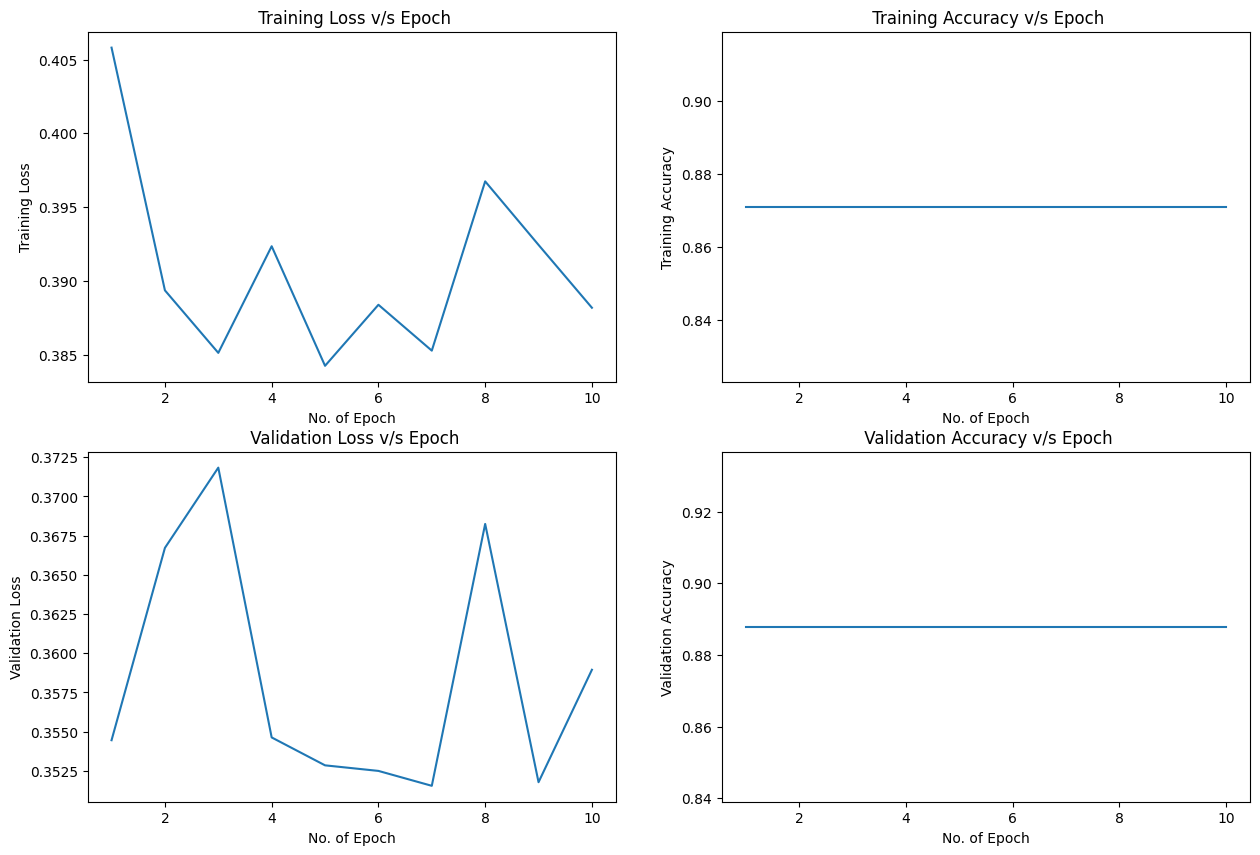

In [109]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.plot(range(1, len(history.history['loss']) + 1), history.history['loss'])
plt.title(' Training Loss v/s Epoch')
plt.xlabel('No. of Epoch')
plt.ylabel('Training Loss')
plt.subplot(2,2,2)
plt.plot(range(1,len(history.history['accuracy'])+1), history.history['accuracy'])
plt.title(' Training Accuracy v/s Epoch')
plt.xlabel('No. of Epoch')
plt.ylabel('Training Accuracy')
plt.subplot(2,2,3)
plt.plot(range(1, len(history.history['val_loss']) + 1), history.history['val_loss'])
plt.title(' Validation Loss v/s Epoch')
plt.xlabel('No. of Epoch')
plt.ylabel('Validation Loss')
plt.subplot(2,2,4)
plt.plot(range(1,len(history.history['val_accuracy'])+1), history.history['val_accuracy'])
plt.title(' Validation Accuracy v/s Epoch')
plt.xlabel('No. of Epoch')
plt.ylabel('Validation Accuracy')

plt.show()

# Prediction - RNN

In [110]:
text1 = ["URGENT! You won a $1,000 Walmart gift card! Click bit.ly to claim it now before it expires!"]    # spam message example
text2 = ["Hey, are we still meeting for lunch at 12:30 PM today?"]      # non spam message example

In [111]:
# # preprocessing

# # convert to sequence of integers
# text1_seq = tokenizer.texts_to_sequences(text1)
# text2_seq = tokenizer.texts_to_sequences(text2)

# # padding to make of same i/p length
# text1_pad = pad_sequences(text1_seq, MAX_LENGTH, padding='post', truncating='post')
# text2_pad = pad_sequences(text2_seq, MAX_LENGTH, padding='post', truncating='post')

In [112]:
# use model to predict whether the text is spam or non-spam
# test1_pred = (RNN_model.predict(text1_pad) > 0.5).astype(int)

In [113]:
# function to predict using the model :

def predict_spam_rnn(text_message):
  # process the text
  text_message_seq = tokenizer.texts_to_sequences([text_message])
  text_message_pad = pad_sequences(text_message_seq, MAX_LENGTH, padding='post', truncating='post')

  # use model to predict whether it is spam or not
  result = RNN_model.predict(text_message_pad)

  # print the result
  if result > 0.5:
    print(f'The message {text_message} is likely spam. Probability = {result}')
  else:
        print(f'The message {text_message} is likely non-spam. Probability = {result}')


In [115]:
predict_spam_rnn(text1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
The message ['URGENT! You won a $1,000 Walmart gift card! Click bit.ly to claim it now before it expires!'] is likely non-spam. Probability = [[0.15623954]]


In [116]:
predict_spam_rnn(text2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
The message ['Hey, are we still meeting for lunch at 12:30 PM today?'] is likely non-spam. Probability = [[0.15623954]]


In [117]:
# inference :
# this result is what we already expected because its a RNN model , and we are only take the top 5000 frequent words when tokenize , so the keywords leads to spam message may skipped

# LSTM - Model Building

In [118]:
LSTM_model = Sequential([
    Embedding(input_dim=5000, output_dim=64),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [119]:
# compile the model

LSTM_model.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics= ['accuracy']
)

In [120]:
LSTM_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [132]:
# Training the LSTM model

# to get the best model
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_lstm_model.keras',     # Where to save the model
    monitor='val_accuracy',          # Metric to monitor
    save_best_only=True,             # Only overwrite if val_accuracy improves
    mode='max',                      # We want maximum accuracy
    verbose=1
)

history_LSTM = LSTM_model.fit(X_test_pad,
                        y_train,
                        validation_split=0.3,
                        epochs = 10,
                        callbacks=[checkpoint_callback],
                        batch_size = 32)

Epoch 1/10
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8435 - loss: 0.4422
Epoch 1: val_accuracy improved from None to 0.89552, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8654 - loss: 0.4008 - val_accuracy: 0.8955 - val_loss: 0.3368
Epoch 2/10
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8743 - loss: 0.3790
Epoch 2: val_accuracy did not improve from 0.89552
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8654 - loss: 0.3970 - val_accuracy: 0.8955 - val_loss: 0.3411
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8539 - loss: 0.4178
Epoch 3: val_accuracy did not improve from 0.89552
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8654 - loss: 0.3972 - val_accuracy: 0.8955 - val_loss: 0.3384
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8705 - loss: 0.3858
Epoch 4: val_accuracy did not improve from 0.89552
25/25 ━━━━━

In [137]:
LSTM_model = tf.keras.models.load_model('best_lstm_model.keras')

In [138]:
# predicting
y_pred_LSTM = (LSTM_model.predict(X_test_pad) > 0.5).astype(int)  # check the condition , if true return 1 else 0

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


# Evaluation - LSTM Model

In [139]:
# test accuracy
test_accuracy_lstm = accuracy_score(y_test, y_pred_LSTM)
print('Accuracy of RNN model is ', test_accuracy_lstm)

Accuracy of RNN model is  0.8663677130044843


In [140]:
history_LSTM.history['loss']

[0.4007893204689026,
 0.3969549238681793,
 0.3972042500972748,
 0.3955972194671631,
 0.3958432376384735,
 0.3976096510887146,
 0.39571452140808105,
 0.3965337872505188,
 0.39663347601890564,
 0.39647841453552246]

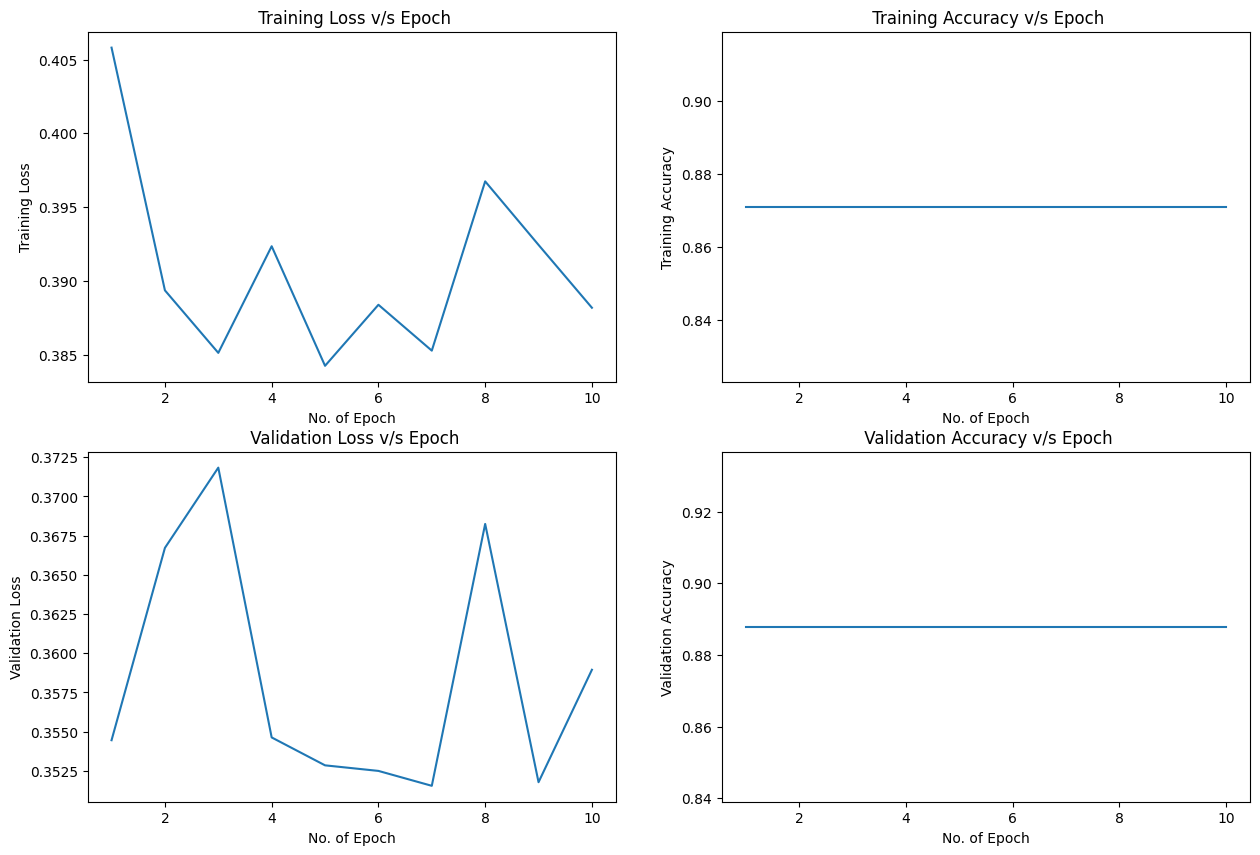

In [141]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.plot(range(1, len(history_LSTM.history['loss']) + 1), history.history['loss'])
plt.title(' Training Loss v/s Epoch')
plt.xlabel('No. of Epoch')
plt.ylabel('Training Loss')
plt.subplot(2,2,2)
plt.plot(range(1,len(history_LSTM.history['accuracy'])+1), history.history['accuracy'])
plt.title(' Training Accuracy v/s Epoch')
plt.xlabel('No. of Epoch')
plt.ylabel('Training Accuracy')
plt.subplot(2,2,3)
plt.plot(range(1, len(history_LSTM.history['val_loss']) + 1), history.history['val_loss'])
plt.title(' Validation Loss v/s Epoch')
plt.xlabel('No. of Epoch')
plt.ylabel('Validation Loss')
plt.subplot(2,2,4)
plt.plot(range(1,len(history_LSTM.history['val_accuracy'])+1), history.history['val_accuracy'])
plt.title(' Validation Accuracy v/s Epoch')
plt.xlabel('No. of Epoch')
plt.ylabel('Validation Accuracy')

plt.show()

# Prediction using LSTM Model

In [142]:
# function to predict using the model :

def predict_spam_lstm(text_message):
  # process the text
  text_message_seq = tokenizer.texts_to_sequences([text_message])
  text_message_pad = pad_sequences(text_message_seq, MAX_LENGTH, padding='post', truncating='post')

  # use model to predict whether it is spam or not
  result = LSTM_model.predict(text_message_pad)

  # print the result
  if result > 0.5:
    print(f'The message {text_message} is likely spam. Probability = {result}')
  else:
        print(f'The message {text_message} is likely non-spam. Probability = {result}')


In [143]:
text1 = ["URGENT! You won a $1,000 Walmart gift card! Click bit.ly to claim it now before it expires!"]    # spam message example
text2 = ["Hey, are we still meeting for lunch at 12:30 PM today?"]      # non spam message example

In [144]:
predict_spam_lstm(text1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
The message ['URGENT! You won a $1,000 Walmart gift card! Click bit.ly to claim it now before it expires!'] is likely non-spam. Probability = [[0.12494648]]


In [145]:
predict_spam_lstm(text2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
The message ['Hey, are we still meeting for lunch at 12:30 PM today?'] is likely non-spam. Probability = [[0.12494648]]
